# Welcome to the Dask Tutorial

<img src="https://docs.dask.org/en/latest/_images/dask_horizontal.svg" align="right" width="30%" alt="Dask logo">

Dask is a parallel and distributed computing library that scales the existing Python and PyData ecosystem.

Dask can scale up to your full laptop capacity and out to a cloud cluster.

**Overview**

In this exercise, you'll use Dask to process a large real-world dataset — NYC Yellow Taxi trips. You'll apply data extraction, cleaning, transformation, and analysis techniques that scale well beyond memory limits.



In [2]:
# import libraries
import dask.dataframe as dd
import pandas as pd
import matplotlib.pyplot as plt


**Task 1: Data Ingestion**

Data is taken from the following link:
https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

In [4]:
df = dd.read_parquet(
    "yellow_tripdata_2023-01.parquet",
)

In [6]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


In [7]:
#number of columns
df.shape[1]
#len(ddf.columns)


19

In [8]:
len(df.columns)

19

In [9]:
df.shape[0].compute()
#len(ddf)

3066766

In [10]:
len(df)

3066766

In [12]:
df.info()

<class 'dask.dataframe.dask_expr.DataFrame'>
Columns: 19 entries, VendorID to airport_fee
dtypes: datetime64[us](2), float64(12), int64(4), string(1)

In [13]:
df.isnull().sum().compute()

VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
RatecodeID               71743
store_and_fwd_flag       71743
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge     71743
airport_fee              71743
dtype: int64

In [14]:
df.memory_usage(deep=True).compute()

Index                         132
VendorID                 24534128
tpep_pickup_datetime     24534128
tpep_dropoff_datetime    24534128
passenger_count          24534128
trip_distance            24534128
RatecodeID               24534128
store_and_fwd_flag       27912497
PULocationID             24534128
DOLocationID             24534128
payment_type             24534128
fare_amount              24534128
extra                    24534128
mta_tax                  24534128
tip_amount               24534128
tolls_amount             24534128
improvement_surcharge    24534128
total_amount             24534128
congestion_surcharge     24534128
airport_fee              24534128
dtype: int64

**Task 2: Data Cleaniing**

Drop rows with missing passenger_count, trip_distance, or total_amount

Remove trips with trip_distance <= 0 or total_amount <= 0

In [27]:
df_clean = df.dropna(subset=['passenger_count', 'RatecodeID', 'store_and_fwd_flag'])
df_clean = df_clean[(df_clean['trip_distance'] > 0) & (df_clean['total_amount'] > 0)]


In [28]:
len(df_clean)

2934435

In [29]:
len(df_clean.columns)

19

In [30]:
num_rows_drop = len(df) - len(df_clean)
num_rows_drop

132331

In [31]:
df_clean.isnull().sum().compute()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
dtype: int64

**Task 3: Data Type Conversion**

Convert datetime columns

In [24]:
df_clean['tpep_pickup_datetime'] = dd.to_datetime(df_clean['tpep_pickup_datetime'])
df_clean['tpep_dropoff_datetime'] = dd.to_datetime(df_clean['tpep_dropoff_datetime'])


In [25]:
df_clean.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


**Task 4: Trip Duration Calculation**

Add a new column for trip duration in minutes

Filter trips longer than 0 and less than 3 hours

In [32]:
df_clean['trip_duration_min'] = (df_clean['tpep_dropoff_datetime'] - df_clean['tpep_pickup_datetime']).dt.total_seconds() / 60
df_clean = df_clean[(df_clean['trip_duration_min'] > 0) & (df_clean['trip_duration_min'] <= 180)]


In [33]:
df_clean.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration_min
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00,8.433333
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00,6.316667
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00,12.750000
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25,9.616667
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00,10.833333


**Task 5: Descriptive Statistic**s

Compute:

  Mean and median trip distance

  Mean fare per minute

  Std. dev. of trip duration



In [34]:
mean_dist = df_clean['trip_distance'].mean().compute()
fare_per_min = (df_clean['total_amount'] / df_clean['trip_duration_min']).mean().compute()
std_duration = df_clean['trip_duration_min'].std().compute()


In [35]:
mean_dist

3.481570694738105

In [36]:
fare_per_min

2.8057650026597303

In [37]:
std_duration

10.978976797198435

**Task 6: Time of Day Analysis**

Number of trips by hour


In [38]:
trips_by_hour = df_clean.groupby(df_clean['tpep_pickup_datetime'].dt.hour)['passenger_count'].count().compute()
trips_by_hour

tpep_pickup_datetime
0      80442
1      56174
2      39210
3      25330
4      15992
5      16318
6      40572
7      81136
8     109982
9     125002
10    137965
11    148073
12    163191
13    171911
14    184451
15    188902
16    187917
17    200670
18    206775
19    185359
20    159533
21    155308
22    141583
23    109582
Name: passenger_count, dtype: int64

**Task 7a: Visualization**

Plot trips_by_hour



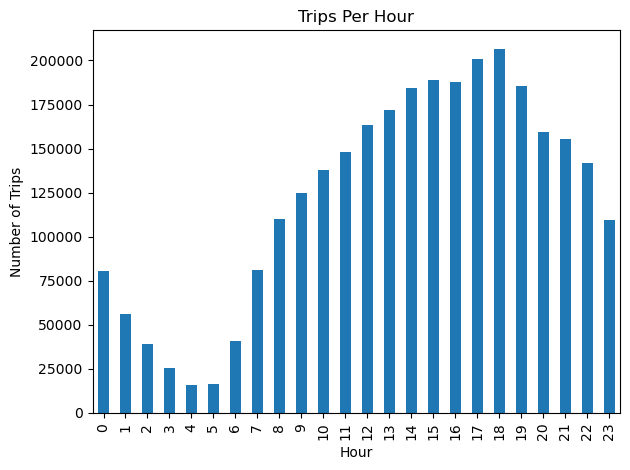

In [39]:
trips_by_hour.plot(kind='bar', title='Trips Per Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Trips')
plt.tight_layout()
plt.show()



**Task 7b: Visualization**

Analyze fare patterns over a 24-hour period.

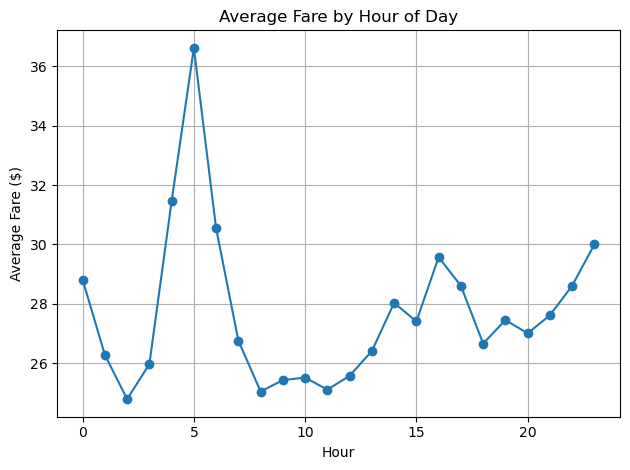

In [40]:
avg_fare_hour = df_clean.groupby(df_clean['tpep_pickup_datetime'].dt.hour)['total_amount'].mean().compute()

avg_fare_hour.plot(kind='line', marker='o', title='Average Fare by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Fare ($)')
plt.grid(True)
plt.tight_layout()
plt.show()


**Task 7c: Distribution of Trip Distances**

Use a histogram to visualize trip distances.

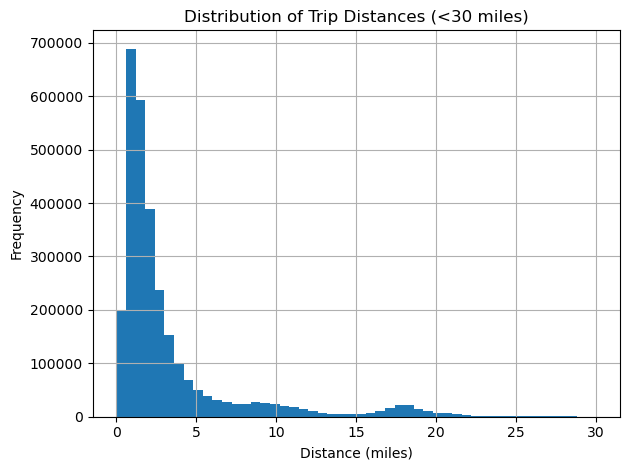

In [41]:
trip_distances = df_clean['trip_distance'].compute()

trip_distances[trip_distances < 30].plot.hist(bins=50, title='Distribution of Trip Distances (<30 miles)')
plt.xlabel('Distance (miles)')
plt.grid(True)
plt.tight_layout()
plt.show()


**Task 7d: Boxplot of Total Amount by Passanger Count**

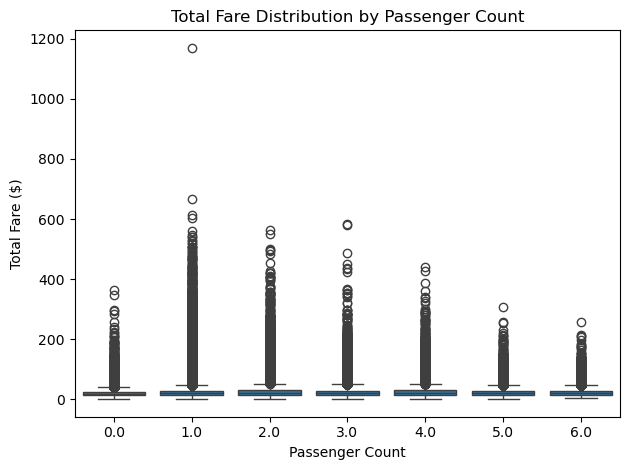

In [42]:
import seaborn as sns

df_plot = df_clean[['passenger_count', 'total_amount']].dropna().compute()
df_plot = df_plot[df_plot['passenger_count'] <= 6]

sns.boxplot(x='passenger_count', y='total_amount', data=df_plot)
plt.title('Total Fare Distribution by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Total Fare ($)')
plt.tight_layout()
plt.show()


**Task 7e: Pickup Volume by Day of Week**

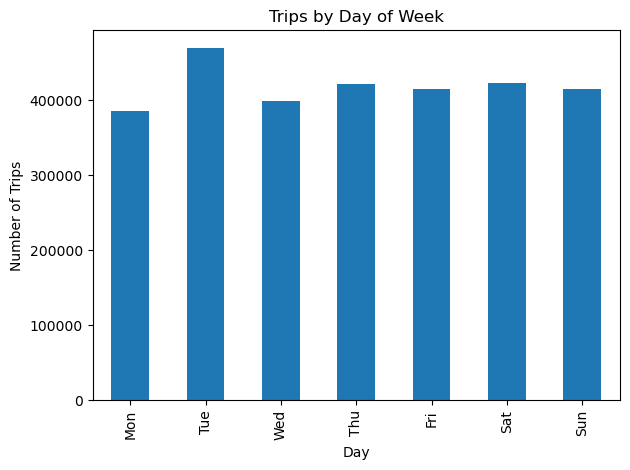

In [43]:
df_clean['day_of_week'] = df_clean['tpep_pickup_datetime'].dt.dayofweek
trips_by_day = df_clean.groupby('day_of_week')['passenger_count'].count().compute()

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
trips_by_day.index = days

trips_by_day.plot(kind='bar', title='Trips by Day of Week')
plt.ylabel('Number of Trips')
plt.xlabel('Day')
plt.tight_layout()
plt.show()


**Task 7f: Trip Duration Distribution**

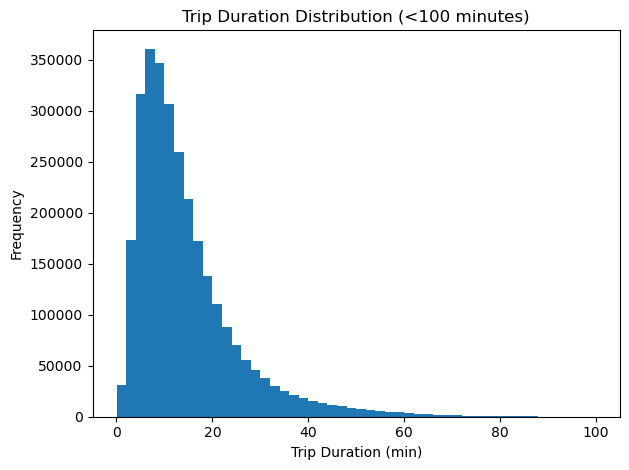

In [44]:
trip_duration = df_clean['trip_duration_min'].compute()
trip_duration[trip_duration < 100].plot.hist(bins=50, title='Trip Duration Distribution (<100 minutes)')
plt.xlabel('Trip Duration (min)')
plt.tight_layout()
plt.show()



**Task 7g: Correlation Heatmap**

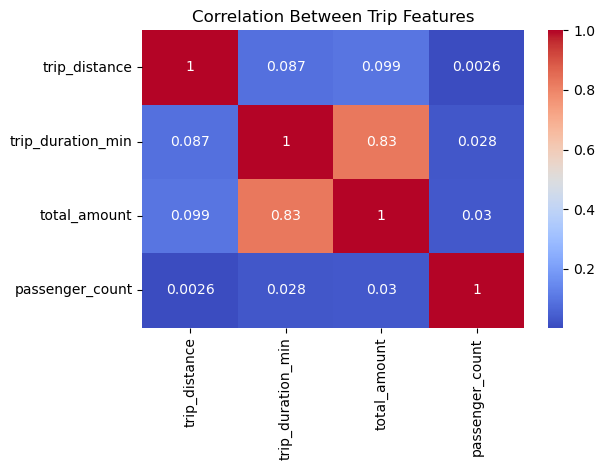

In [46]:
df_corr = df_clean[['trip_distance', 'trip_duration_min', 'total_amount', 'passenger_count']].compute()
corr_matrix = df_corr.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Between Trip Features')
plt.tight_layout()
plt.show()


**Task 8: Unique Passanger Count**

In [47]:
unique_count = df['passenger_count'].nunique().compute()
unique_count


10

In [48]:
unique_value_count = df['passenger_count'].value_counts().compute()
unique_value_count

passenger_count
0.0      51164
1.0    2261400
2.0     451536
3.0     106353
4.0      53745
5.0      42681
6.0      28124
7.0          6
8.0         13
9.0          1
Name: count, dtype: int64

In [49]:
unique_value_counts_sorted = df['passenger_count'].value_counts().compute().sort_values(ascending=False)
unique_value_counts_sorted

passenger_count
1.0    2261400
2.0     451536
3.0     106353
4.0      53745
0.0      51164
5.0      42681
6.0      28124
8.0         13
7.0          6
9.0          1
Name: count, dtype: int64

**Task 9: Which passanger count gives the maximum and minimum tip_amount**

In [50]:
result = df.groupby("passenger_count").tip_amount.mean().compute()
result

passenger_count
0.0     2.870892
1.0     3.324993
2.0     3.589881
3.0     3.370632
4.0     3.281927
5.0     3.383753
6.0     3.355087
7.0     9.470000
8.0    13.389231
9.0     0.000000
NaN     3.733109
Name: tip_amount, dtype: float64